In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
# Cargar el dataset
df = pd.read_csv("autos2.csv")
df.head()
#Limpiar datos con "?"
df = df.replace("?", np.nan)

In [ ]:
df = df.apply(pd.to_numeric, errors="ignore")
df = df.dropna()

/tmp/ipykernel_241/4465855.py:1: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore")


In [ ]:
X = df[['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore']]
y = df['price']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Error cuadrático medio (MSE): {mse_rf:.2f}")
print(f"Coeficiente de determinación (R²): {r2_rf:.2f}")

Error cuadrático medio (MSE): 5640193.65
Coeficiente de determinación (R²): 0.68


In [ ]:
import numpy as np
# Calcular el RMSE (mas facil de interpretar que el MSE)
rmse = np.sqrt(mse_rf)
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")

Raíz del Error cuadrático medio (RMSE): 2374.91


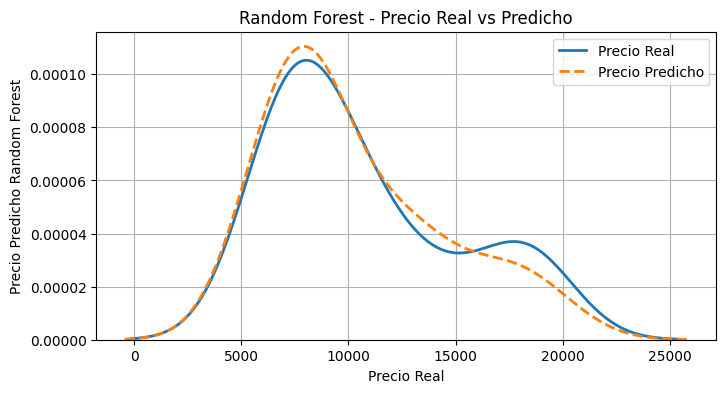

In [ ]:
# Comparación visual de distribuciones
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_rf, label='Precio Predicho', linewidth=2, linestyle='--')
plt.title('Random Forest - Precio Real vs Predicho')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho Random Forest')
plt.legend()
plt.grid(True)
plt.show()


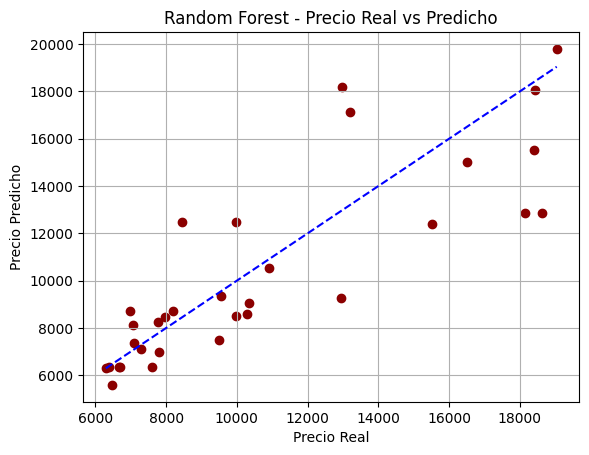

In [ ]:
plt.scatter(y_test, y_pred_rf, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') # Línea ideal
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Random Forest - Precio Real vs Predicho")
plt.grid(True)
plt.show()

In [ ]:
# Modelo con parámetros ajustados
rf_model = RandomForestRegressor(
n_estimators=200, # más árboles
max_depth=8, # limitar profundidad
min_samples_split=4, # evitar divisiones con pocos datos
min_samples_leaf=3, # cada hoja al menos con 3 observaciones
max_features='sqrt', # usa raíz cuadrada del total de features
random_state=42
)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")
print(f"RMSE: {np.sqrt(mse):.2f}")

MSE: 4564032.56
R²: 0.74
RMSE: 2136.36


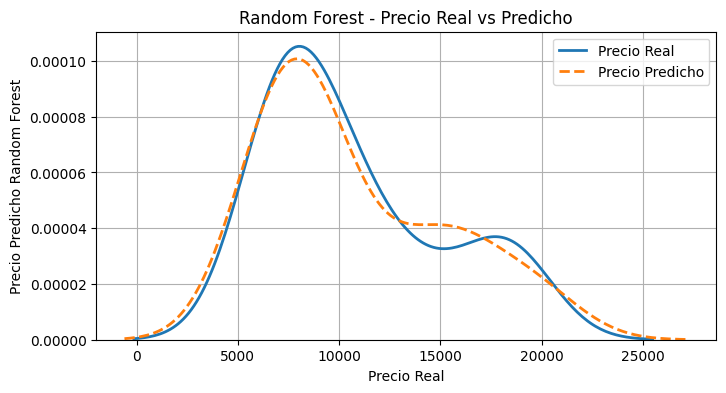

In [ ]:
# Comparación visual de distribuciones
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.title('Random Forest - Precio Real vs Predicho')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho Random Forest')
plt.legend()
plt.grid(True)
plt.show()


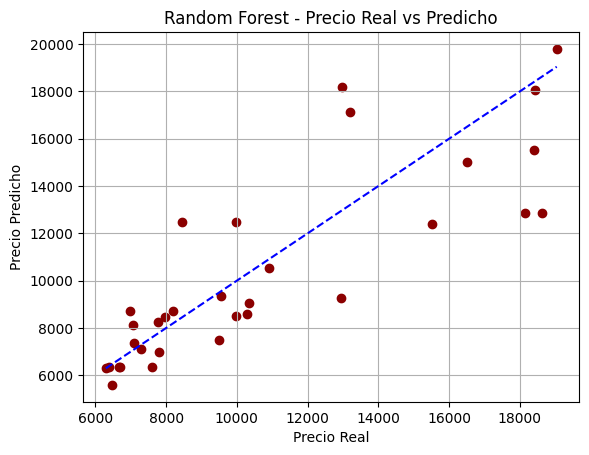

In [ ]:
plt.scatter(y_test, y_pred_rf, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') # Línea ideal
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Random Forest - Precio Real vs Predicho")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
'n_estimators': [100, 200, 300],
'max_depth': [4, 6, 8, None],
'min_samples_split': [2, 4, 6],
'min_samples_leaf': [1, 2, 3],
'max_features': ['sqrt', 'log2']
}
grid_search = GridSearchCV(
RandomForestRegressor(random_state=42),
param_grid,
cv=3, # validación cruzada
scoring='r2',
n_jobs=-1,
verbose=2
)
grid_search.fit(X_train, y_train)
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor R²:", grid_search.best_score_)


Fitting 3 folds for each of 216 candidates, totalling 648 fits
Mejores parámetros: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 100}
Mejor R²: 0.8792781495314026


MSE: 4756681.86
R²: 0.73
RMSE: 2180.98


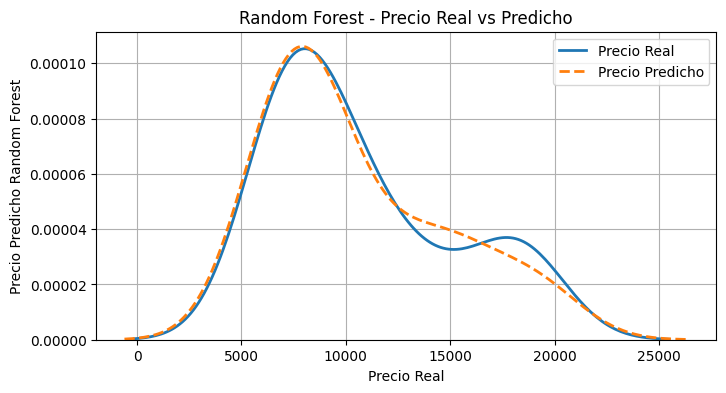

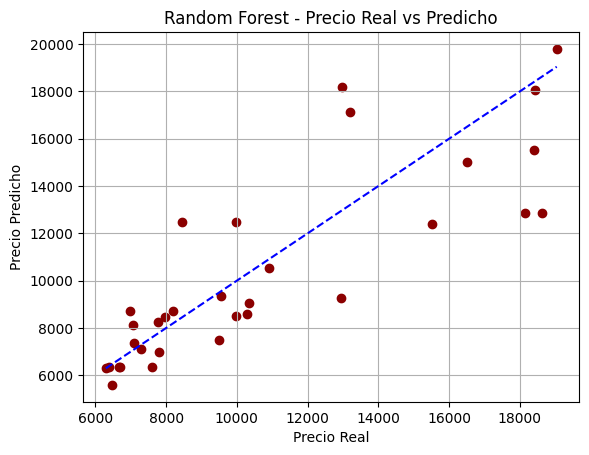

In [ ]:
# Modelo con parámetros ajustados
rf_model = RandomForestRegressor(
n_estimators=300, # más árboles
max_depth=8, # limitar profundidad
min_samples_split=2, # evitar divisiones con pocos datos
min_samples_leaf=1, # cada hoja al menos con 1 observaciones
max_features='sqrt', # usa raíz cuadrada del total de features
random_state=42
)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")
print(f"RMSE: {np.sqrt(mse):.2f}")
# Comparación visual de distribuciones
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.title('Random Forest - Precio Real vs Predicho')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho Random Forest')
plt.legend()
plt.grid(True)
plt.show()
plt.scatter(y_test, y_pred_rf, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') # Línea ideal
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Random Forest - Precio Real vs Predicho")
plt.grid(True)
plt.show()